In [3]:
############################## Accept-Reject Algorithm ######################

import numpy as np
import matplotlib.pyplot as plt

def target_function(x):
    x = np.asarray(x)
    bump = np.sin(6 * x) ** 2 + 3 * np.cos(x) ** 2 * np.sin(4 * x) ** 2 + 1
    return np.exp(-x**2 / 2) * bump

def envelope_function(x):
    x = np.asarray(x)
    return 5 * np.exp(-x**2 / 2)


#1. sample X ~ g(x): N(0,1) and U~ Uniform[0,1]
rng = np.random.default_rng(7)
num_samples = int(1e5)
x_from_proposal_distribution = rng.normal(0, 1, num_samples)
u_from_standard_unifrom = rng.uniform(0, 1, num_samples)

accept_prob = target_function(x_from_proposal_distribution) / envelope_function(x_from_proposal_distribution)
accept = u_from_standard_unifrom < accept_prob
accepted_X = x_from_proposal_distribution[accept]
rejected_X = x_from_proposal_distribution[~accept]
accepted_U = u_from_standard_unifrom[accept]
rejected_U = u_from_standard_unifrom[~accept]

area = len(accepted_X)/num_samples

print(f"Acceptance rate: {area:.4f}")
print(f"Accepted samples: {len(accepted_X)} / {num_samples}")


Acceptance rate: 0.4707
Accepted samples: 47070 / 100000


### Exact normalization integral

For the target shape

$$
f(x)=e^{-x^2/2}\Big(\sin^2(6x)+3\cos^2(x)\sin^2(4x)+1\Big),
$$

the exact integral over $\mathbb{R}$ is

$$
\int_{-\infty}^{\infty} f(x)\,dx
=\sqrt{2\pi}\left(
\frac94
+\frac34 e^{-2}
-\frac38 e^{-18}
-\frac34 e^{-32}
-\frac38 e^{-50}
-\frac12 e^{-72}
\right)
\approx 5.89434003924.
$$

If we use the envelope $g(x)=5e^{-x^2/2}$, then the acceptance probability is

$$
\mathbb{P}(\text{accept})
=\frac{\int_{-\infty}^{\infty} f(x)\,dx}{\int_{-\infty}^{\infty} 5e^{-x^2/2}\,dx}
=\frac{1}{5\sqrt{2\pi}}\int_{-\infty}^{\infty} f(x)\,dx
\approx 0.4703002913.
$$


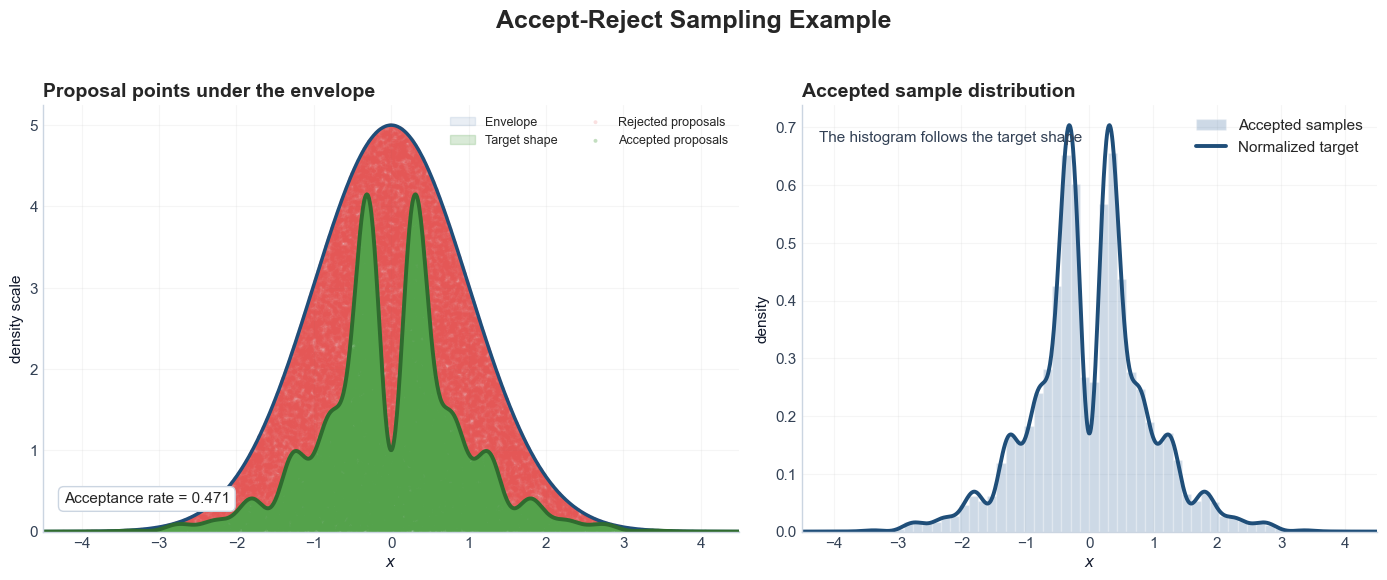

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CBD5E1",
    "axes.labelcolor": "#0F172A",
    "xtick.color": "#334155",
    "ytick.color": "#334155",
    "font.size": 11,
})

grid = np.linspace(-4.5, 4.5, 900)
target = target_function(grid)
envelope = envelope_function(grid)
target_density = target / np.trapz(target, grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.15, 0.95]})
fig.suptitle("Accept-Reject Sampling Example", fontsize=18, fontweight="bold", y=1.03)

# Left panel: geometry of the sampler
ax = axes[0]
ax.fill_between(grid, 0, envelope, color="#4C78A8", alpha=0.12, label="Envelope")
ax.fill_between(grid, 0, target, color="#54A24B", alpha=0.22, label="Target shape")
ax.plot(grid, envelope, color="#1F4E79", lw=2.5)
ax.plot(grid, target, color="#2F6B2F", lw=2.8)
ax.scatter(rejected_X, rejected_U * envelope_function(rejected_X), s=8, color="#E45756", alpha=0.18, edgecolors="none", label="Rejected proposals")
ax.scatter(accepted_X, accepted_U * envelope_function(accepted_X), s=8, color="#54A24B", alpha=0.35, edgecolors="none", label="Accepted proposals")
ax.set_title("Proposal points under the envelope", loc="left", fontsize=14, fontweight="bold")
ax.set_xlabel("$x$")
ax.set_ylabel("density scale")
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(0, envelope.max() * 1.05)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper right")
ax.text(
    0.03,
    0.06,
    f"Acceptance rate = {area:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#CBD5E1"},
)

# Right panel: accepted sample distribution
ax2 = axes[1]
ax2.hist(accepted_X, bins=55, density=True, color="#4C78A8", alpha=0.28, edgecolor="white", label="Accepted samples")
ax2.plot(grid, target_density, color="#1F4E79", lw=2.8, label="Normalized target")
ax2.set_title("Accepted sample distribution", loc="left", fontsize=14, fontweight="bold")
ax2.set_xlabel("$x$")
ax2.set_ylabel("density")
ax2.set_xlim(-4.5, 4.5)
ax2.legend(frameon=False)
ax2.text(
    0.03,
    0.94,
    "The histogram follows the target shape",
    transform=ax2.transAxes,
    ha="left",
    va="top",
    color="#334155",
)

for a in axes:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.grid(True, alpha=0.18)

fig.tight_layout()
